# Lab 18: PCA on a larger sample dataset

Built-in digits: 1,797 rows and 64 features. This is a manageable larger sample dataset, not production-scale data. PCA/scaling are fit on training data only; compares held-out classification before/after 95%-variance reduction.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


Dataset shape: (1797, 64)
95% variance PCA components: 40
Retained variance: 0.9528126674266866
Full-feature test accuracy: 0.9777777777777777
PCA test accuracy: 0.96


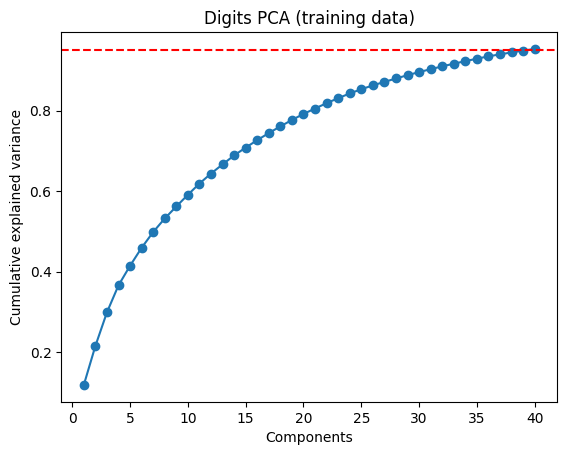

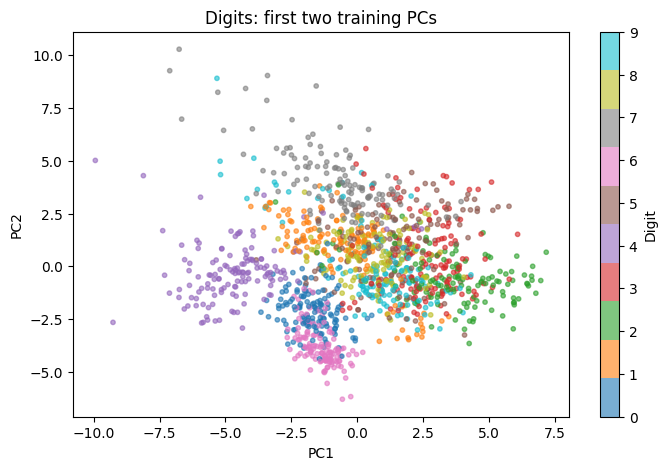

In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
D=load_digits();X_train,X_test,y_train,y_test=train_test_split(D.data,D.target,test_size=.25,random_state=42,stratify=D.target)
scaler=StandardScaler();A=scaler.fit_transform(X_train);B=scaler.transform(X_test)
pca=PCA(n_components=.95,svd_solver='full');Z_train=pca.fit_transform(A);Z_test=pca.transform(B)
base=LogisticRegression(max_iter=2000).fit(A,y_train);reduced=LogisticRegression(max_iter=2000).fit(Z_train,y_train)
print('Dataset shape:',D.data.shape);print('95% variance PCA components:',pca.n_components_);print('Retained variance:',pca.explained_variance_ratio_.sum());print('Full-feature test accuracy:',accuracy_score(y_test,base.predict(B)));print('PCA test accuracy:',accuracy_score(y_test,reduced.predict(Z_test)))
plt.figure();plt.plot(np.arange(1,len(pca.explained_variance_ratio_)+1),np.cumsum(pca.explained_variance_ratio_),marker='o');plt.axhline(.95,color='red',linestyle='--');plt.xlabel('Components');plt.ylabel('Cumulative explained variance');plt.title('Digits PCA (training data)');plt.show()
plt.figure(figsize=(8,5));plt.scatter(Z_train[:,0],Z_train[:,1],c=y_train,cmap='tab10',s=10,alpha=.6);plt.xlabel('PC1');plt.ylabel('PC2');plt.title('Digits: first two training PCs');plt.colorbar(label='Digit');plt.show()
